# Датасет - Титаник
### Структура данных

| Признак | Описание |
|---------|----------|
|survival| Выжил? (0 - нет, 1 - да)|
|pclass	| Класс билета (1 = 1st, 2 = 2nd, 3 = 3rd)|
|sex| Пол|	
|Age| Возраст|	
|sibsp|	Количество братьев и сестер/супругов на борту Титаника|
|parch|	Количество родителей/детей на борту Титаника|
|ticket| Номер билета|
|fare| Стоимость билета|
|cabin|	Номер каюты |
|embarked| Порт отправления (C = Cherbourg, Q = Queenstown, S = Southampton)|


## Загрузка данных и библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from IPython.display import display


# Настройка отображения
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', None)
sns.set(font_scale=1.2)

# 1. Загрузка данных
print("1. Загрузка данных")
df = pd.read_csv('train.csv')

1. Загрузка данных


## A) Быстрый обзор данных

In [2]:
df.info()
df.describe(include='all')
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


(891, 12)

In [3]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
df.tail(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.7500,NaN,Q


In [5]:
display(df.isnull().sum())
display(df.isnull().mean().sort_values(ascending=False))

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Cabin          0.771044
Age            0.198653
Embarked       0.002245
PassengerId    0.000000
Name           0.000000
Pclass         0.000000
Survived       0.000000
Sex            0.000000
Parch          0.000000
SibSp          0.000000
Fare           0.000000
Ticket         0.000000
dtype: float64

Больше всего пропусков в Cabin и Age

In [6]:
(df[['Age','Fare','SibSp','Parch']] < 0).sum()

Age      0
Fare     0
SibSp    0
Parch    0
dtype: int64

In [7]:
for col in ["Sex","Embarked","Pclass"]:
    print(df[col].value_counts())

Sex
male      577
female    314
Name: count, dtype: int64
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


## Б) Пропуски и отчистка

### Заполняем пропуски в Age
Возраст зависит от пола и класса билета, поэтому группируем по полу и классу (то есть 6 групп) и в каждой группе заполняем пропуски медианой
Выбрал медиану потому что более устойчива к выбросам и лучше отражает средний возраст в нашем случае

In [8]:
df.groupby(['Sex','Pclass'])['Age'].median()

Sex     Pclass
female  1         35.0
        2         28.0
        3         21.5
male    1         40.0
        2         30.0
        3         25.0
Name: Age, dtype: float64

<Axes: xlabel='Pclass', ylabel='Age'>

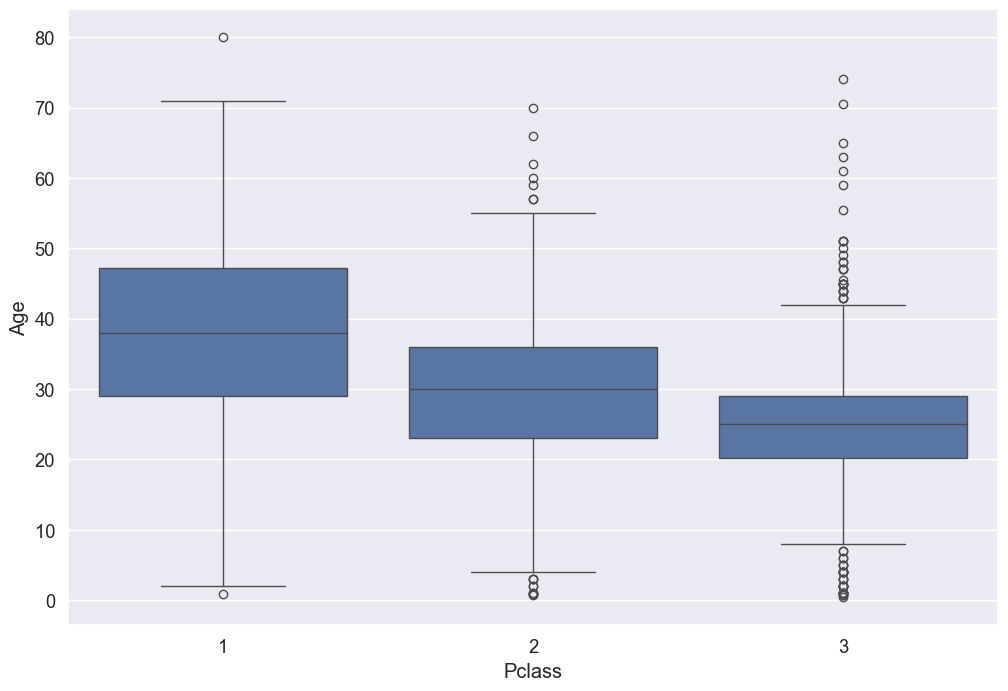

In [9]:
df['Age'] = df.groupby(['Sex','Pclass'])['Age'].transform(
    lambda x: x.fillna(x.median())
)
sns.boxplot(x='Pclass', y='Age', data=df)

Поле порт заполняем модой

In [10]:
df.fillna({'Embarked': df['Embarked'].mode()[0]}, inplace=True)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.5,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [11]:
df['Cabin_known'] = df['Cabin'].notnull().astype(int)
df.drop(columns='Cabin', inplace=True)

In [12]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Cabin_known    0
dtype: int64

Избавились от всех пропусков

## В) Расширенная статистика

In [13]:
num_cols = df.select_dtypes(include=np.number).drop(columns=['PassengerId'])
stats = pd.DataFrame({
    "min": num_cols.min(),
    "max": num_cols.max(),
    "mean": num_cols.mean(),
    "median": num_cols.median(),
    "mode": num_cols.mode().iloc[0]
})

stats

,min,max,mean,median,mode
Survived,0.00,1.0000,0.383838,0.0000,0.00
Pclass,1.00,3.0000,2.308642,3.0000,3.00
Age,0.42,80.0000,29.112424,26.0000,25.00
SibSp,0.00,8.0000,0.523008,0.0000,0.00
Parch,0.00,6.0000,0.381594,0.0000,0.00
Fare,0.00,512.3292,32.204208,14.4542,8.05
Cabin_known,0.00,1.0000,0.228956,0.0000,0.00


Из всех значений самый показательные это процент выживших, самый многолюдный класс, мин макс и самый частый, средняя стоимость билета

In [14]:
percentiles = num_cols.quantile([0.05, 0.25, 0.75, 0.95])
percentiles

,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin_known
0.05,0.0,1.0,6.0,0.0,0.0,7.22500,0.0
0.25,0.0,2.0,21.5,0.0,0.0,7.91040,0.0
0.75,1.0,3.0,36.0,1.0,0.0,31.00000,0.0
0.95,1.0,3.0,54.0,3.0,2.0,112.07915,1.0


In [15]:
summary = pd.concat([
    num_cols.min().rename("min"),
    num_cols.max().rename("max"),
    num_cols.mean().rename("mean"),
    num_cols.median().rename("median"),
    num_cols.mode().iloc[0].rename("mode"),
    num_cols.quantile(0.05).rename("p5"),
    num_cols.quantile(0.25).rename("p25"),
    num_cols.quantile(0.95).rename("p95")
], axis=1)

summary

,min,max,mean,median,mode,p5,p25,p95
Survived,0.00,1.0000,0.383838,0.0000,0.00,0.000,0.0000,1.00000
Pclass,1.00,3.0000,2.308642,3.0000,3.00,1.000,2.0000,3.00000
Age,0.42,80.0000,29.112424,26.0000,25.00,6.000,21.5000,54.00000
SibSp,0.00,8.0000,0.523008,0.0000,0.00,0.000,0.0000,3.00000
Parch,0.00,6.0000,0.381594,0.0000,0.00,0.000,0.0000,2.00000
Fare,0.00,512.3292,32.204208,14.4542,8.05,7.225,7.9104,112.07915
Cabin_known,0.00,1.0000,0.228956,0.0000,0.00,0.000,0.0000,1.00000


In [16]:
variance = num_cols.var()
variance

Survived          0.236772
Pclass            0.699015
Age             177.007700
SibSp             1.216043
Parch             0.649728
Fare           2469.436846
Cabin_known       0.176734
dtype: float64

In [17]:
skewness = num_cols.skew()
skewness

Survived       0.478523
Pclass        -0.630548
Age            0.534083
SibSp          3.695352
Parch          2.749117
Fare           4.787317
Cabin_known    1.292367
dtype: float64

In [18]:
kurtosis = num_cols.kurtosis()
kurtosis

Survived       -1.775005
Pclass         -1.280015
Age             0.717067
SibSp          17.880420
Parch           9.778125
Fare           33.398141
Cabin_known    -0.330535
dtype: float64

In [19]:
full_stats = pd.concat([
    num_cols.min().rename("min"),
    num_cols.max().rename("max"),
    num_cols.mean().rename("mean"),
    num_cols.median().rename("median"),
    num_cols.mode().iloc[0].rename("mode"),
    num_cols.quantile(0.05).rename("p5"),
    num_cols.quantile(0.25).rename("p25"),
    num_cols.quantile(0.95).rename("p95"),
    num_cols.var().rename("дисперсия"),
    num_cols.skew().rename("асимметрия"),
    num_cols.kurtosis().rename("эксцесс")
], axis=1)

full_stats

,min,max,mean,median,mode,p5,p25,p95,дисперсия,асимметрия,эксцесс
Survived,0.00,1.0000,0.383838,0.0000,0.00,0.000,0.0000,1.00000,0.236772,0.478523,-1.775005
Pclass,1.00,3.0000,2.308642,3.0000,3.00,1.000,2.0000,3.00000,0.699015,-0.630548,-1.280015
Age,0.42,80.0000,29.112424,26.0000,25.00,6.000,21.5000,54.00000,177.007700,0.534083,0.717067
SibSp,0.00,8.0000,0.523008,0.0000,0.00,0.000,0.0000,3.00000,1.216043,3.695352,17.880420
Parch,0.00,6.0000,0.381594,0.0000,0.00,0.000,0.0000,2.00000,0.649728,2.749117,9.778125
Fare,0.00,512.3292,32.204208,14.4542,8.05,7.225,7.9104,112.07915,2469.436846,4.787317,33.398141
Cabin_known,0.00,1.0000,0.228956,0.0000,0.00,0.000,0.0000,1.00000,0.176734,1.292367,-0.330535


## Г) Энкодинг

In [20]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Cabin_known
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


In [21]:
df = pd.get_dummies(df, columns=['Sex','Embarked'], drop_first=True)

In [22]:
df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin_known,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,0,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,1,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,0,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,1,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,0,True,False,True


## Д) Визуализация

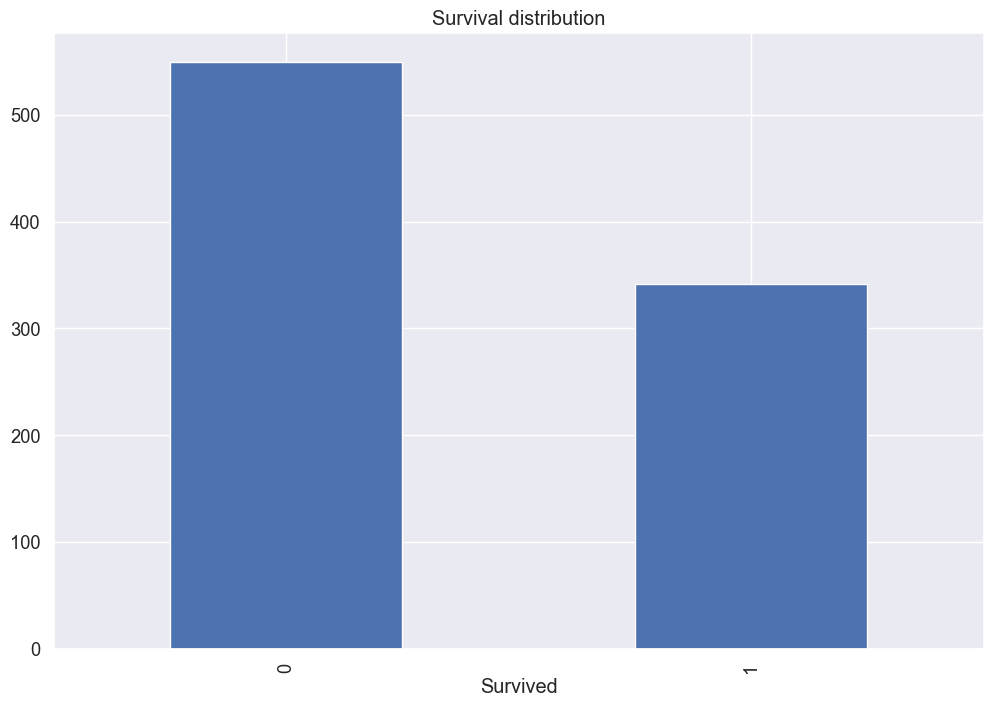

In [26]:
df['Survived'].value_counts().plot(kind='bar')
plt.title("Survival distribution")
plt.show()

<Axes: xlabel='Pclass', ylabel='Survived'>

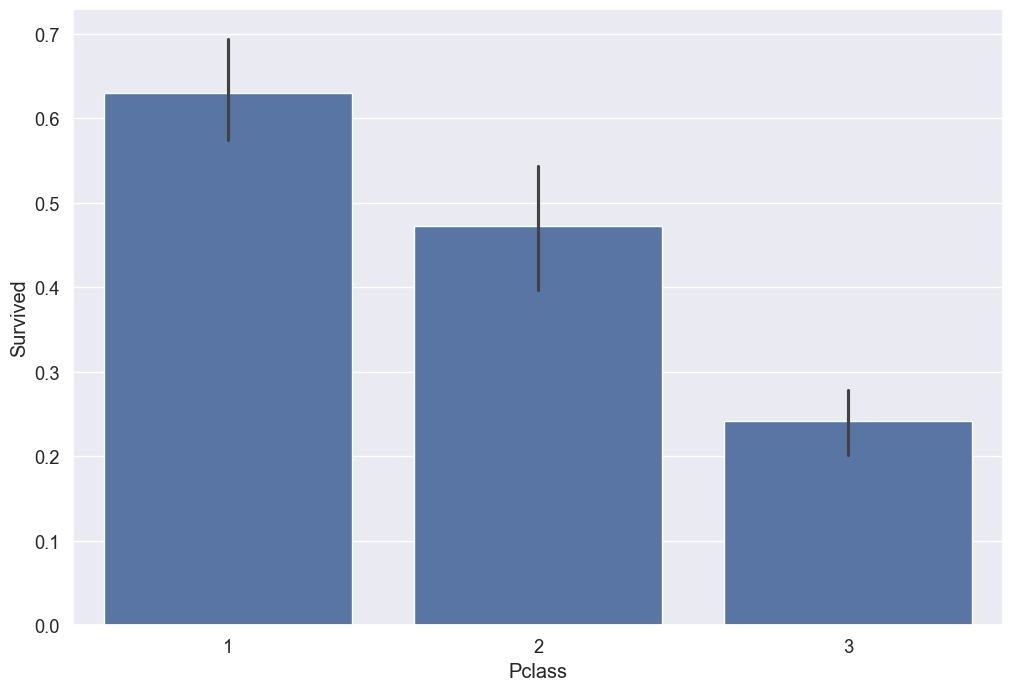

In [27]:
sns.barplot(x='Pclass', y='Survived', data=df)

<Axes: xlabel='Age', ylabel='Count'>

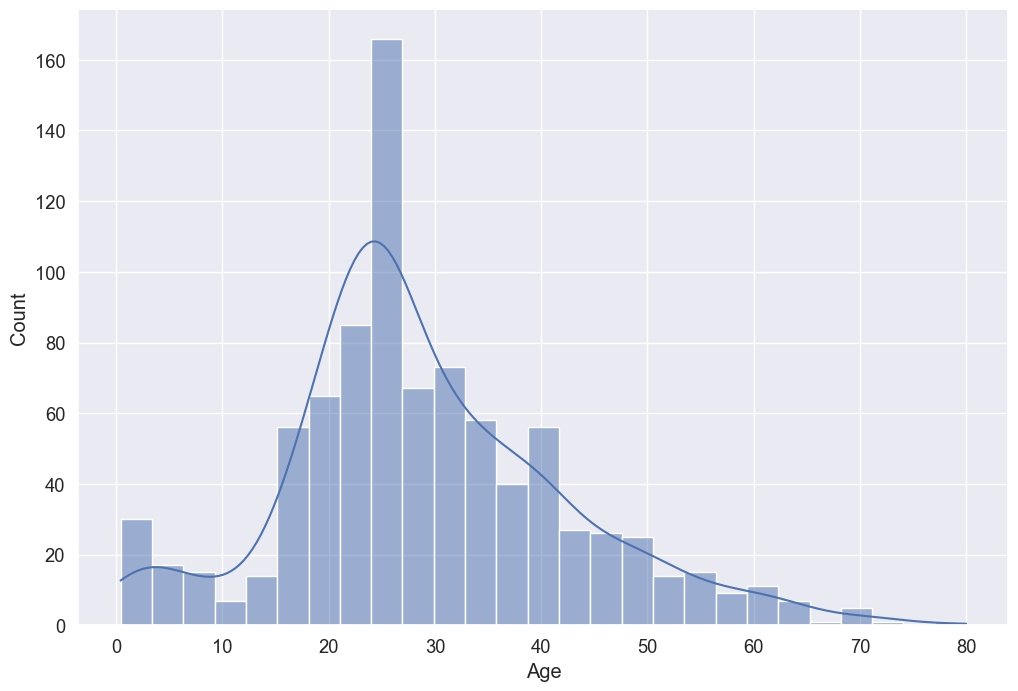

In [28]:
sns.histplot(df['Age'], kde=True)

<Axes: xlabel='Survived', ylabel='Age'>

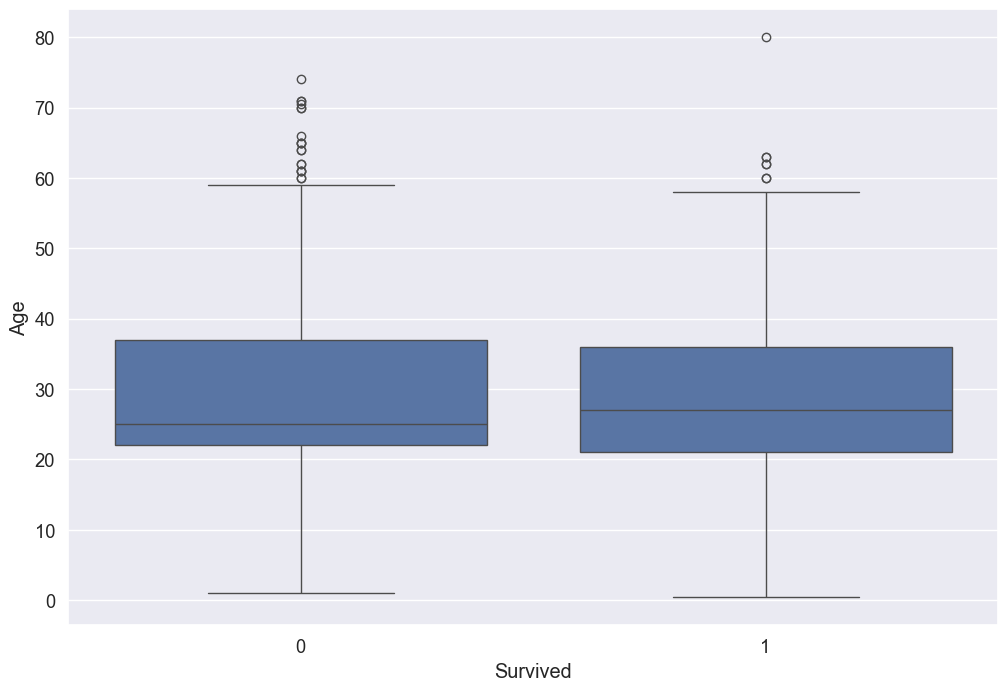

In [30]:
sns.boxplot(x='Survived', y='Age', data=df)

<Axes: >

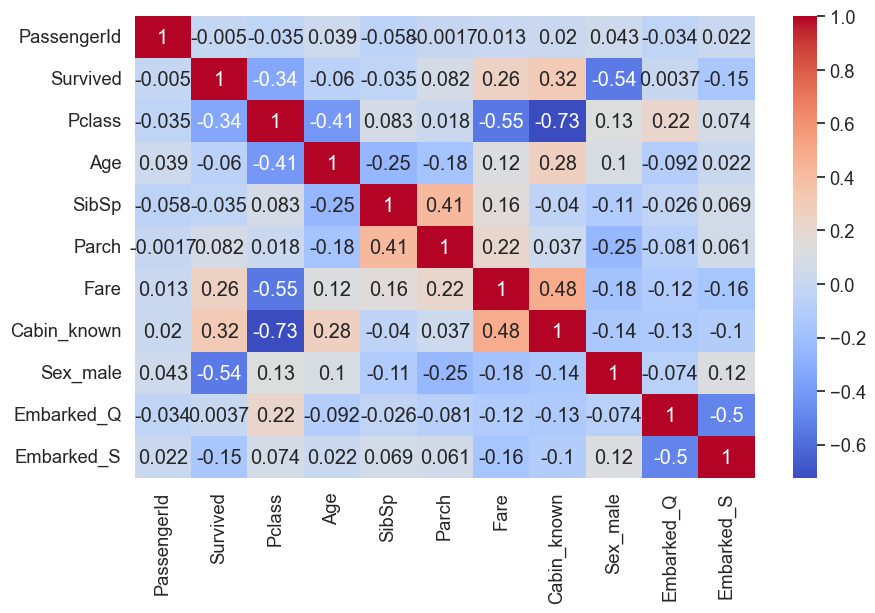

In [32]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

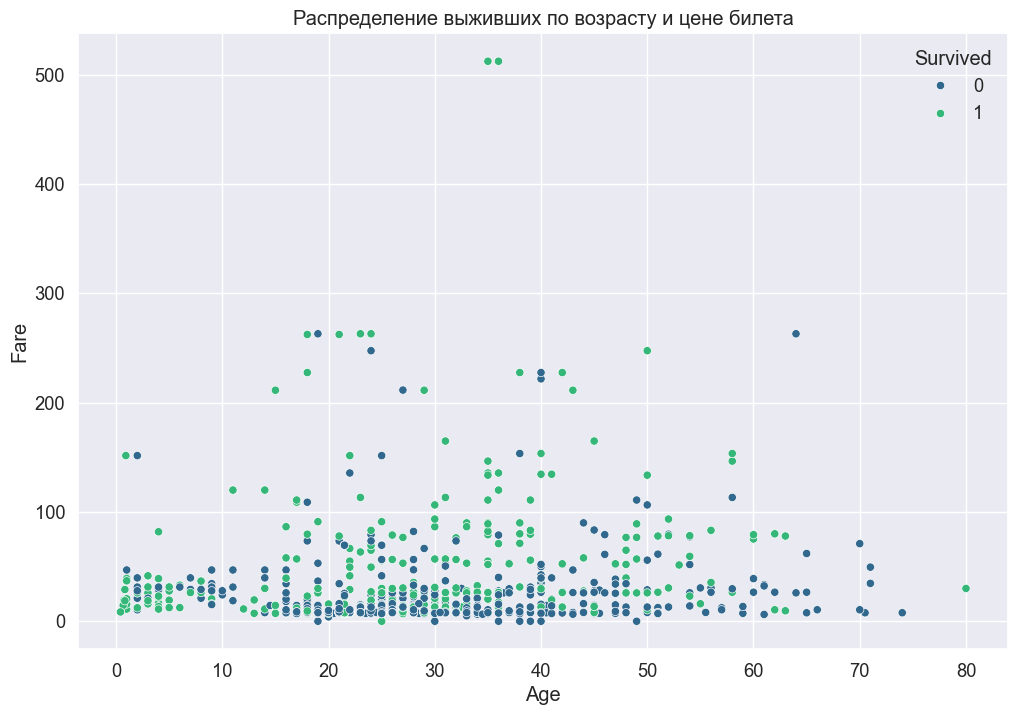

In [37]:
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived', palette='viridis')

plt.title('Распределение выживших по возрасту и цене билета')
plt.show()

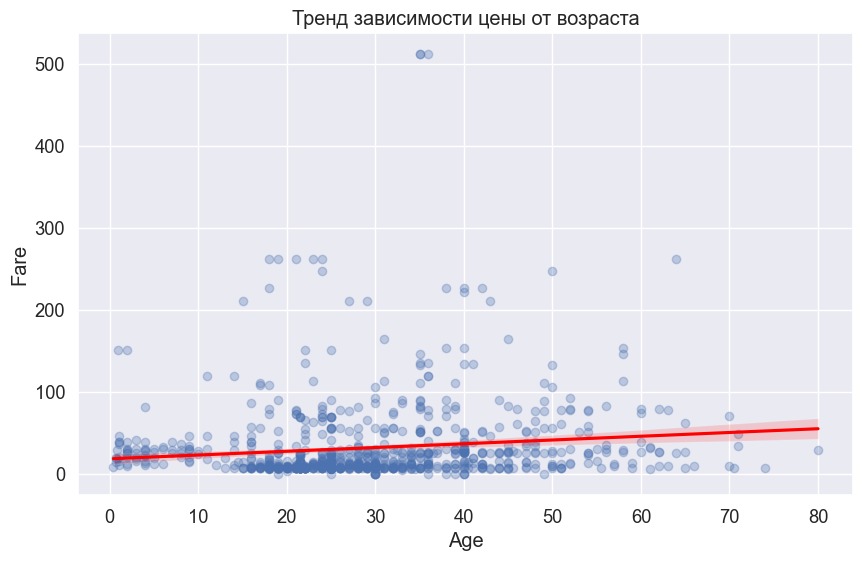

In [38]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Age', y='Fare', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Тренд зависимости цены от возраста')
plt.show()